# Cumulative grid-connected PV systems by size class - Germany, end of 2024

Redraw of the left pie of the Fraunhofer ISE figure ("Total Installations and Share of
Grid-Connected PV Systems"): **4,833,446 systems** split into six nameplate-power classes,
each wedge labelled with its count (German thousands separator) and share.

Small building systems dominate by count: **67 % are up to 10 kWp** (3,232,819 systems) and
93 % stay below 30 kWp; systems above 500 kWp make up under 2 %.

Shares are the rounded percentages printed in the original figure, not recomputed from the
counts. The figure is written to `<date>_<time>_out_<i>.pdf` next to this notebook.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 11

In [ ]:
from datetime import datetime
from pathlib import Path

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
OUT_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str) -> Path:
    """Next '<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    return OUT_DIR / f"{OUT_RUN_STAMP}_out_{out_index}.{file_format}"


In [17]:
# Segment labels, counts and the original chart colours (Office 2007/2010 palette)
labels = [
    'Building (x \u2264 10 kWp)',
    'Building (10 < x < 20 kWp)',
    'Building (20 \u2264 x < 30 kWp)',
    'Building (30 \u2264 x < 100 kWp)',
    'Building (100 \u2264 x < 500 kWp)',
    'PV systems > 500 kWp',
]

values = [3_232_819, 965_582, 312_394, 196_873, 50_988, 74_790]

# Percentages as printed in the original Fraunhofer ISE figure (its own rounding)
shares = [67, 20, 7, 4, 1, 1]

colors = [
    '#4472A8',  # blue
    '#B84B4B',  # red
    '#98B44E',  # green
    '#7D64A0',  # purple
    '#4AACC5',  # teal
    '#F79646',  # orange
]

total = sum(values)
print(f'Total grid-connected PV systems: {total:,}')

Total grid-connected PV systems: 4,833,446


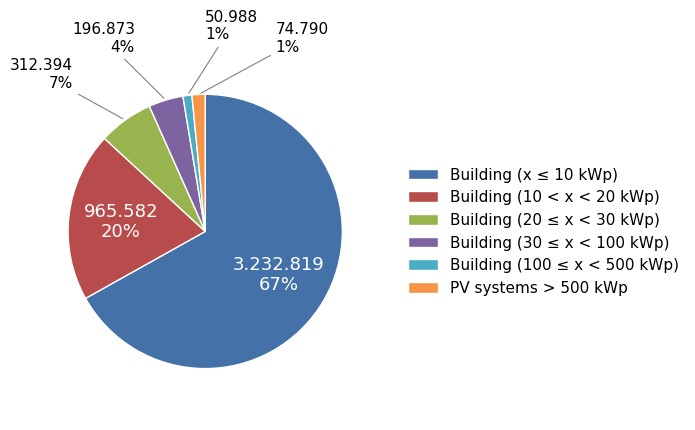

In [18]:
def de_format(n):
    """Format an integer with '.' as the thousands separator (German style)."""
    return f'{n:,}'.replace(',', '.')

fig, ax = plt.subplots(figsize=(7, 7))

R = 0.8  # pie radius (< 1 leaves breathing room around the chart)
wedges, _ = ax.pie(
    values,
    colors=colors,
    radius=R,
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.0},
)

# Big slices (>= 15%): label sits inside the wedge in white.
# Small slices: their wedges are all clustered at the top of the pie, so their
# callouts are fanned across a wide arc (upper-left -> top -> upper-right),
# keeping each near its own wedge while spreading them enough not to overlap.
small_idx = [i for i, s in enumerate(shares) if s < 15]
label_ang = np.linspace(130, 70, len(small_idx))  # fanned angles, ordered like the wedges
label_r = R + 0.40  # push callouts out so the fanned labels clear one another

for i, (wedge, value, share) in enumerate(zip(wedges, values, shares)):
    ang = np.deg2rad((wedge.theta2 + wedge.theta1) / 2.0)
    x, y = np.cos(ang), np.sin(ang)
    text = f'{de_format(value)}\n{share:.0f}%'

    if share >= 15:  # inside label
        ax.text(0.62 * R * x, 0.62 * R * y, text, ha='center', va='center',
                color='white', fontsize=13)
    else:            # callout fanned around its own section
        la = np.deg2rad(label_ang[small_idx.index(i)])
        tx, ty = label_r * np.cos(la), label_r * np.sin(la)
        ax.annotate(
            text,
            xy=(R * x, R * y), xycoords='data',
            xytext=(tx, ty), textcoords='data',
            ha='right' if tx < 0 else 'left', va='center', fontsize=11,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.8,
                            connectionstyle='arc3,rad=0.0'),
        )

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')

# Legend on the right, single column, matching wedge order
ax.legend(wedges, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
          frameon=False, fontsize=11, ncol=1)

plt.tight_layout()

# PDF export (mandatory) + PNG for quick preview
out_path = next_out_path('pdf')
fig.savefig(out_path, bbox_inches='tight')
print(f'saved {out_path}')
plt.show()